# Section 3 — BDC & fund filings: the loan-level layer

Thin driver notebook: all logic lives in `src/edgar/`.

- **Form ADV** (`scrape_adv.py`): 3 dated bulk snapshots (2012/2018/2026) for a real historical manager-count/RAUM trend.
- **Bank-loan fund N-PORT** (`scrape_nport.py`): shares parsing logic with Section 2 via `src/common/nport.py`.
- **BDC Schedules of Investment** (`scrape_bdc_soi.py`): the mission brief's suggested approach (parsing the combined 10-K/10-Q HTML) doesn't work — the SOI isn't in a normal `<table>` there. The real fix: EDGAR's per-statement XBRL-rendered report fragment, reshaped from its long "Investment, Identifier [Axis]" format. 5/8 tracked BDCs parsed successfully this run; failures are logged per-filing, not fatal.
- **Entity resolution** (`analysis_resolution.py`): the match-cascade funnel is itself an exhibit (`viz_funnel.py`).
- **Mark dispersion** (`analysis_mark_dispersion.py`): the signature "one loan, several prices" piece — real cross-filer mark disagreement, coverage today is 2+ filers per issuer (the mission brief's >=3 bar needs more BDCs parsing successfully).

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

from IPython.display import Image, display

from src.edgar import (
    scrape_bdc_soi, scrape_nport, scrape_adv,
    analysis_resolution, analysis_mark_dispersion, analysis_crowding, analysis_terms, analysis_managers,
    viz_dispersion, viz_crowding, viz_terms, viz_funnel,
)

/Users/zinuoshi/clo-atlas/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## Scrape (raw -> interim)

In [2]:
RUN_SCRAPE = False
if RUN_SCRAPE:
    scrape_bdc_soi.run()
    scrape_nport.run()
    scrape_adv.run()

## Analysis (interim -> final)

In [3]:
resolution = analysis_resolution.run()
dispersion = analysis_mark_dispersion.run()
crowding = analysis_crowding.run()
terms = analysis_terms.run()
managers = analysis_managers.run()

maturity date isn't a clean structured field in the BDC SOI XBRL fragment; maturity_wall is empty rather than guessed from free text


## Viz (final -> figures/)

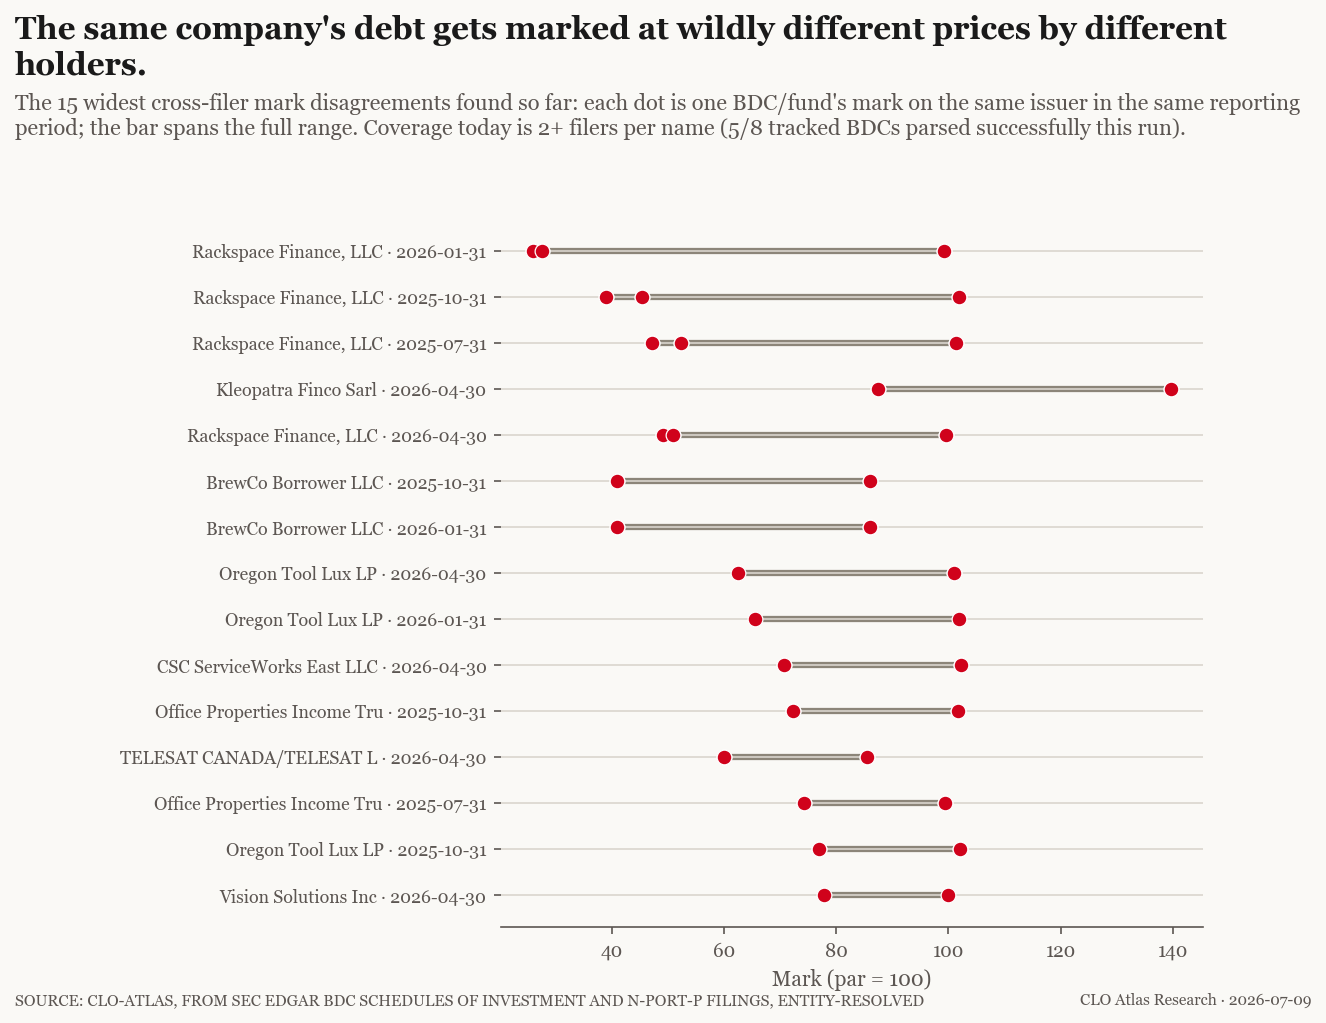

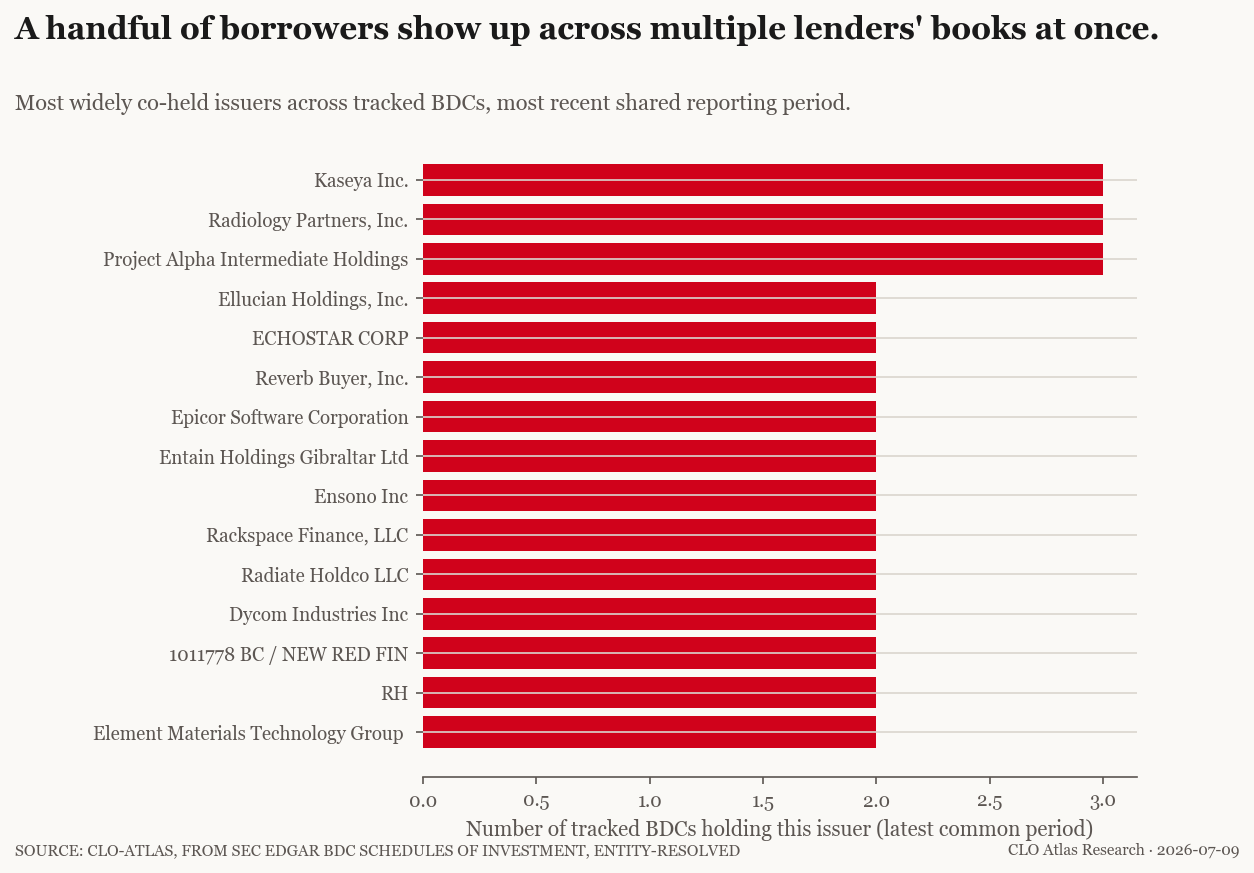

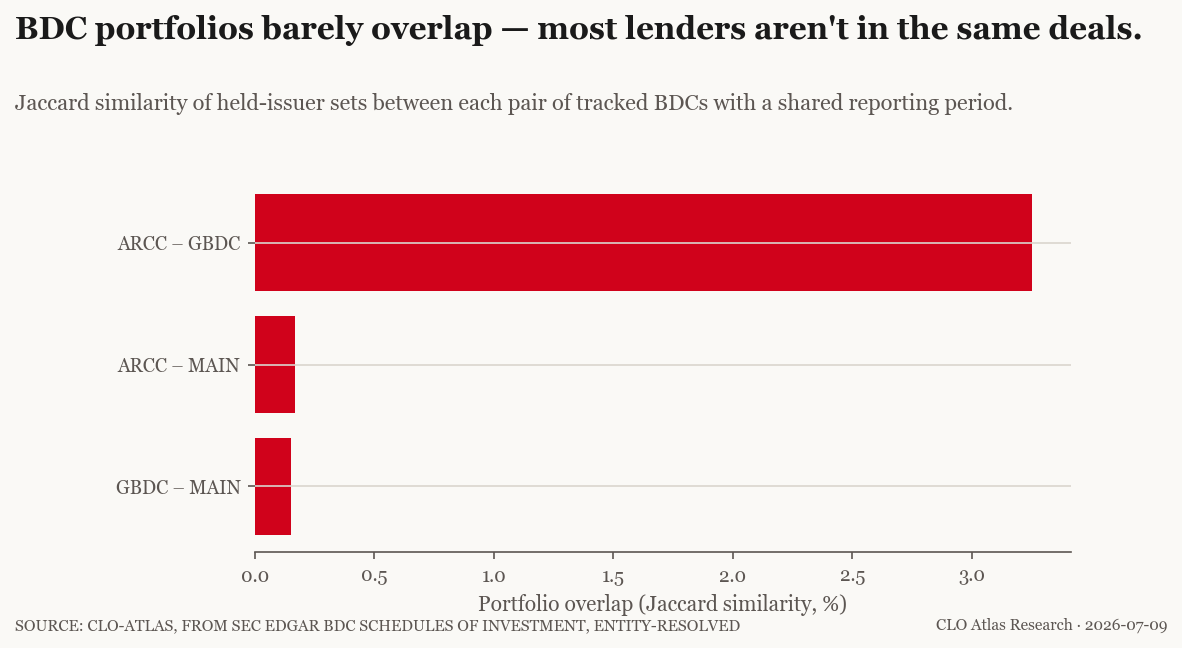

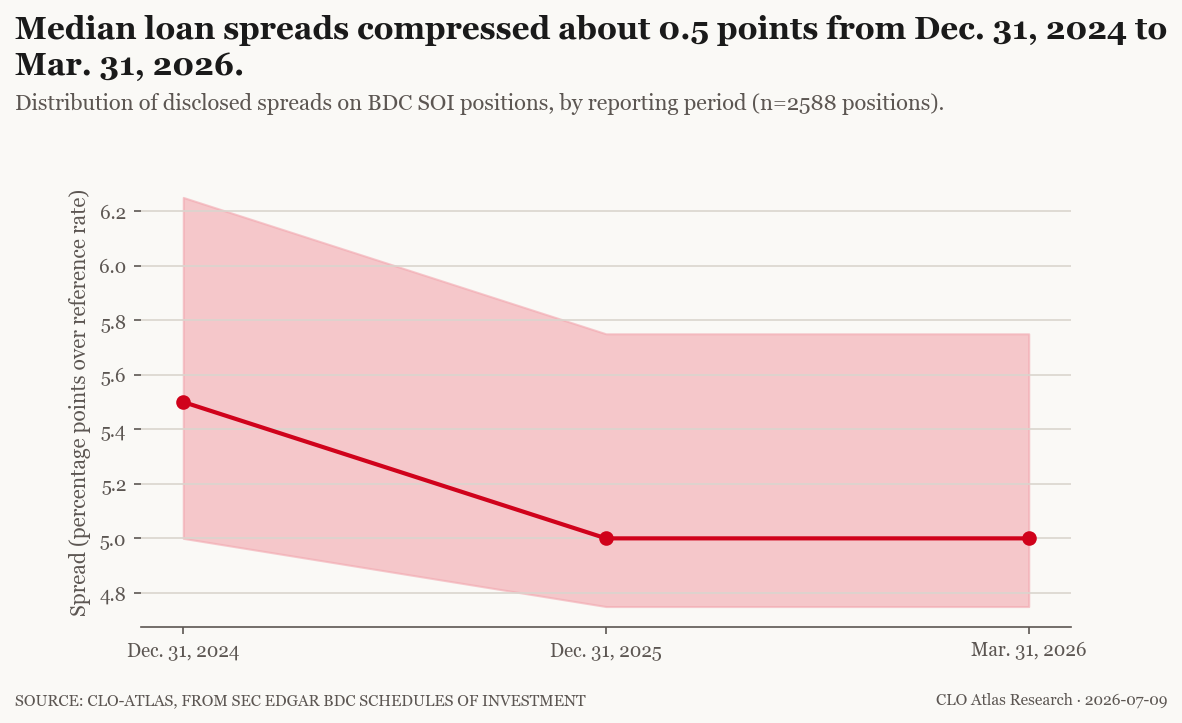

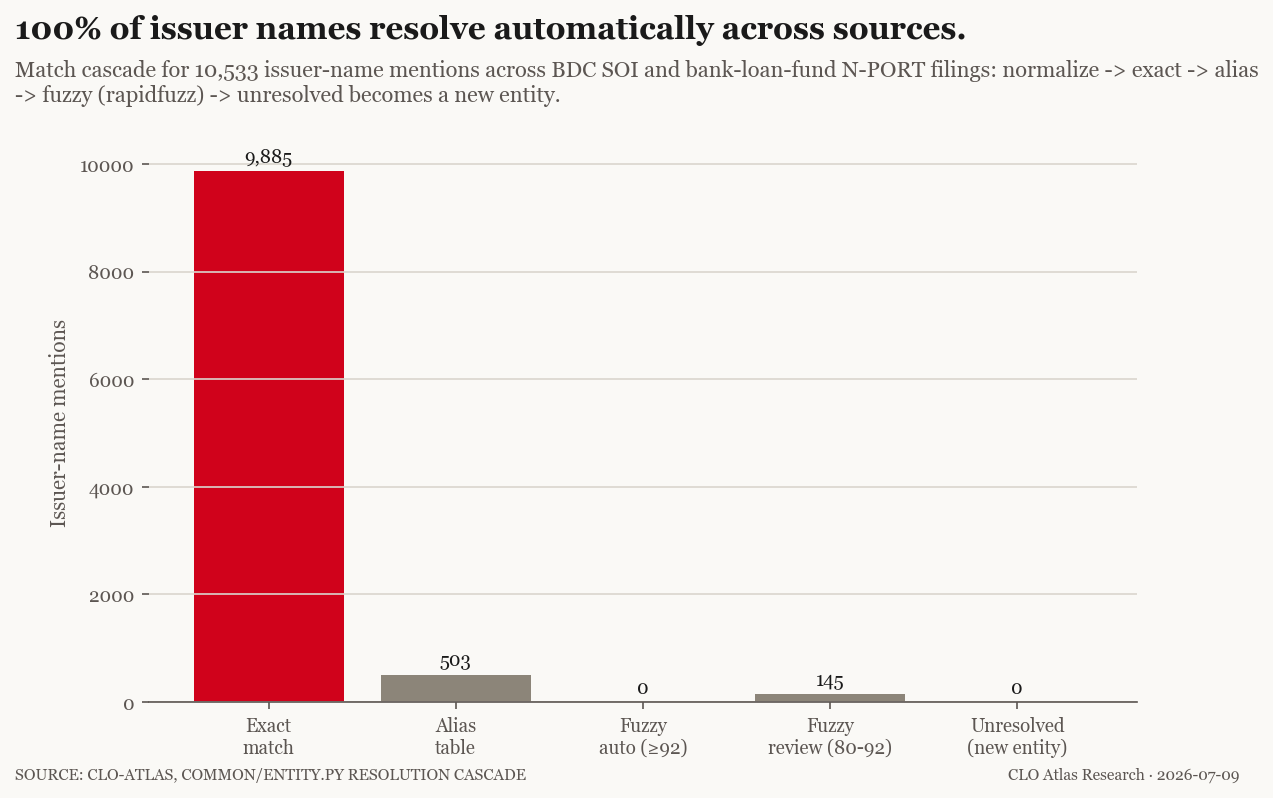

In [4]:
viz_dispersion.run()
viz_crowding.run()
viz_terms.run()
viz_funnel.run()

## Exhibits

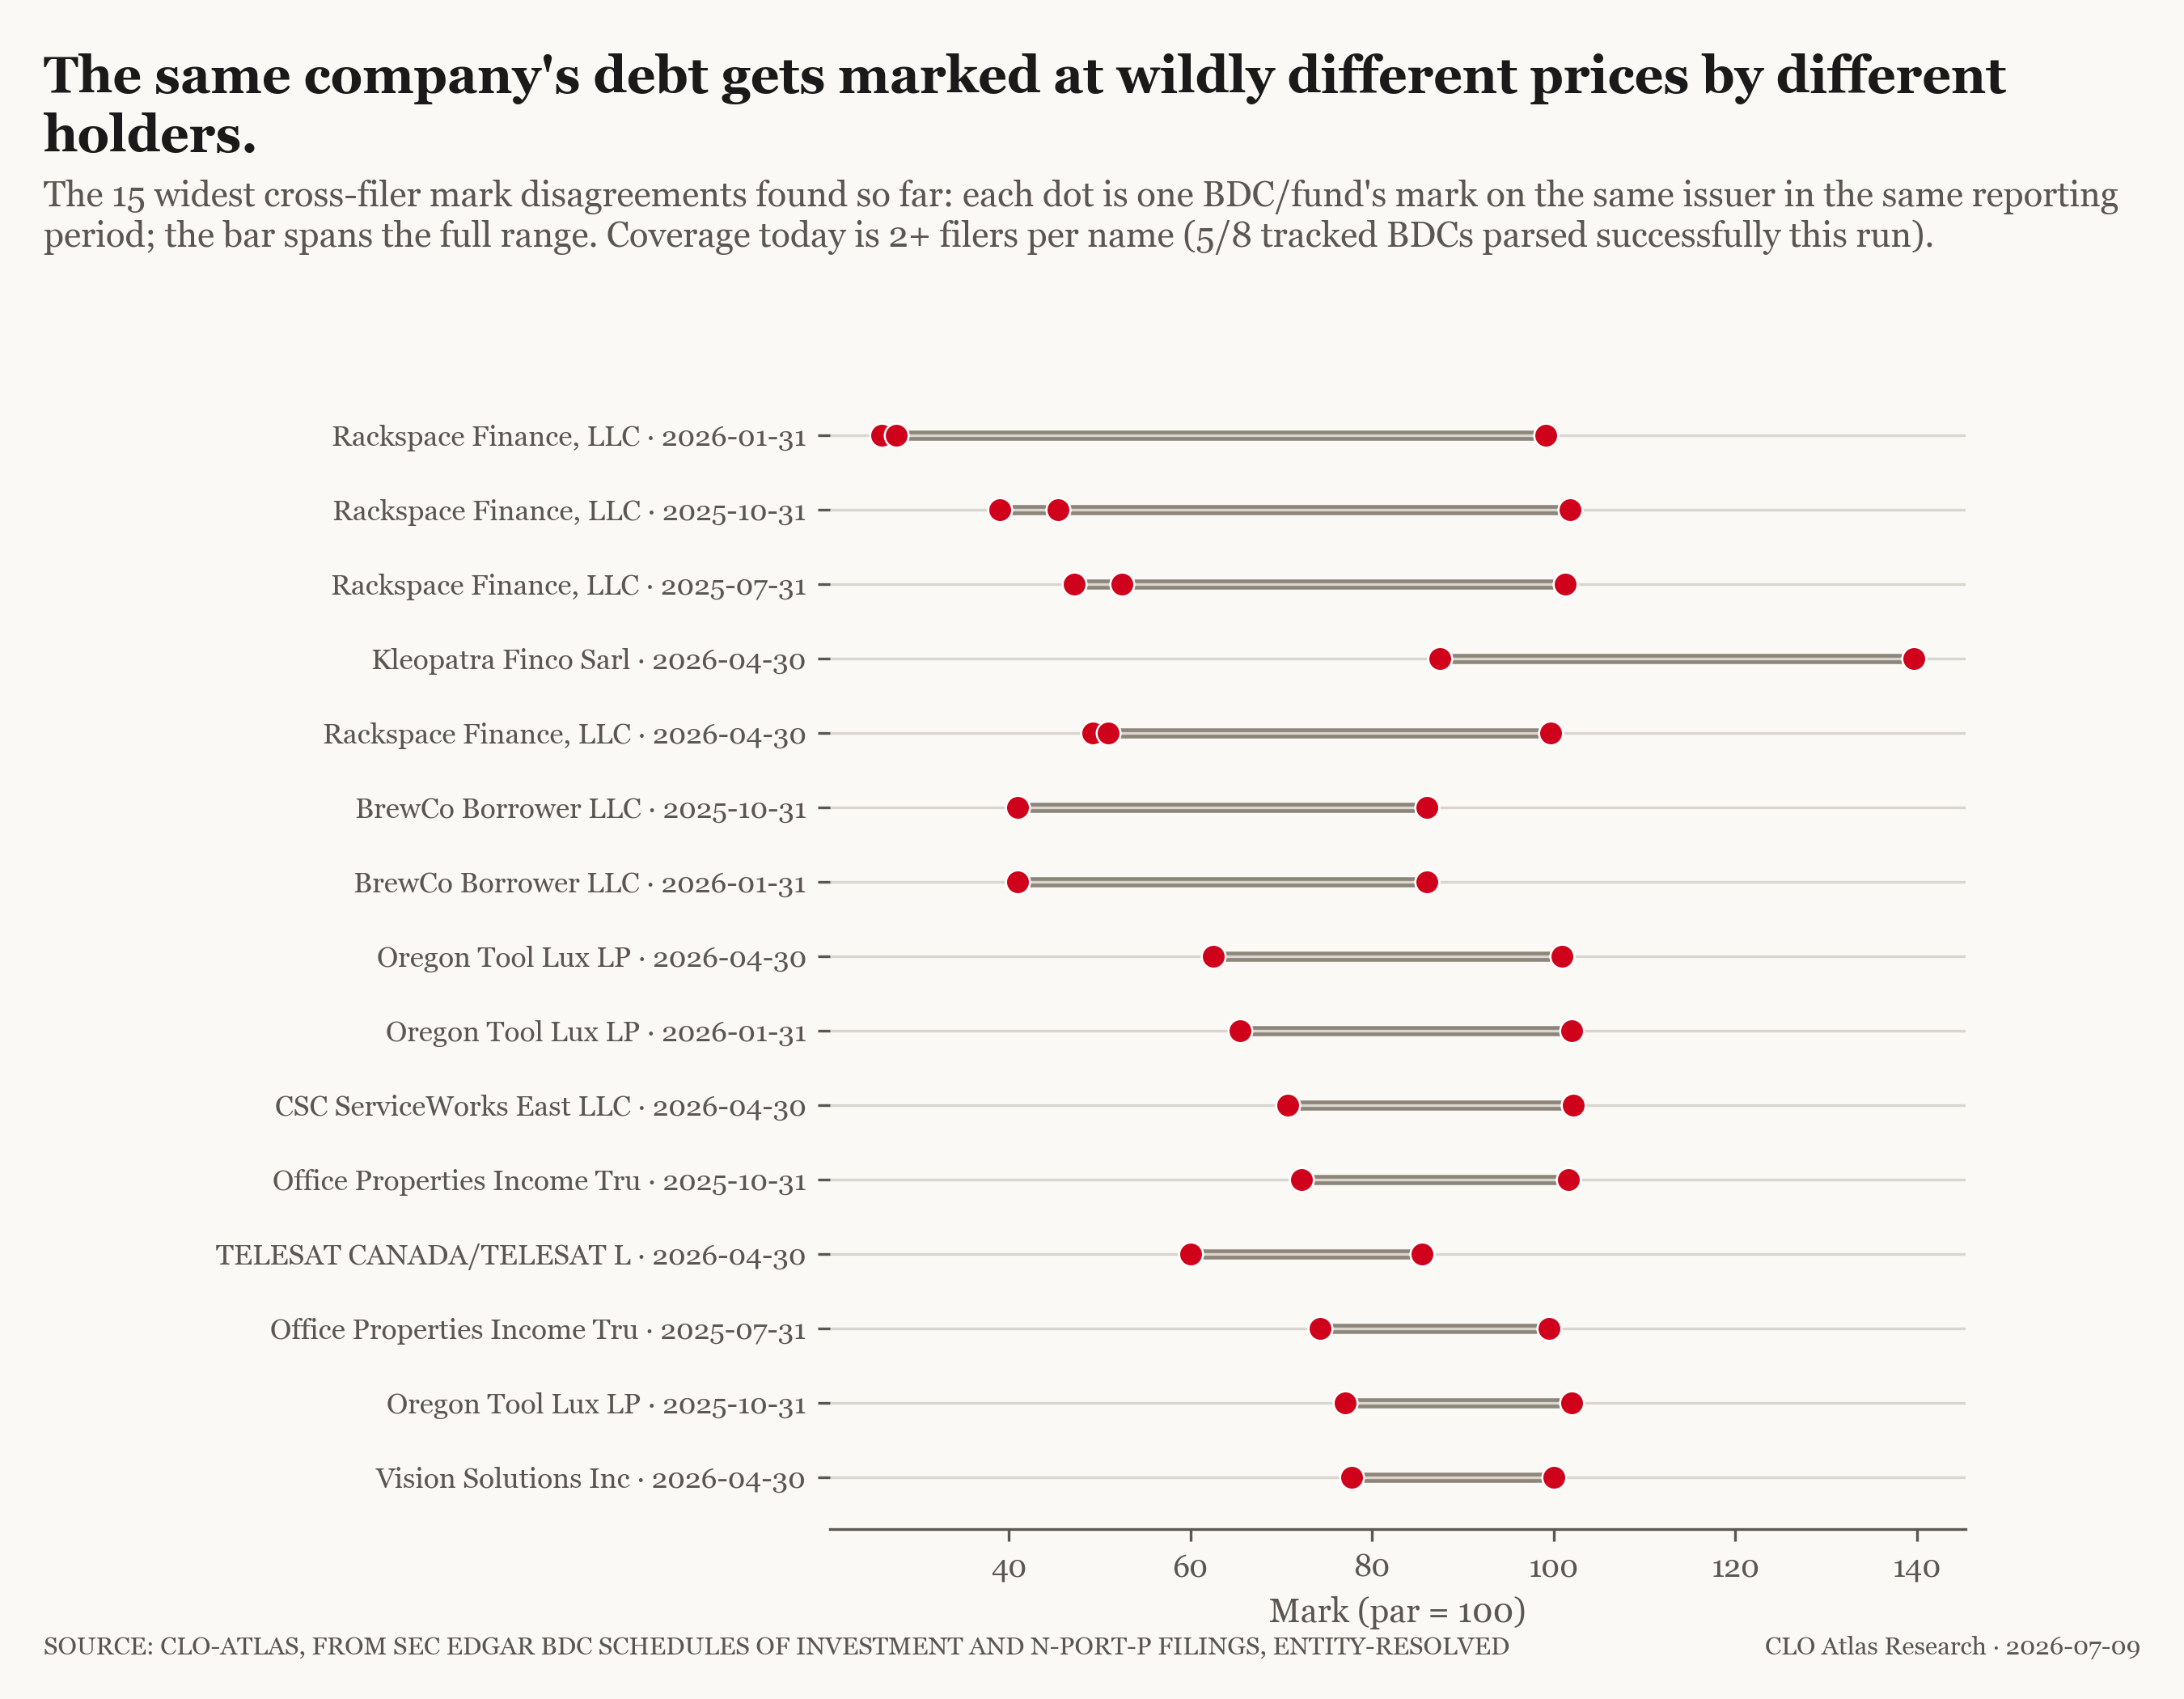

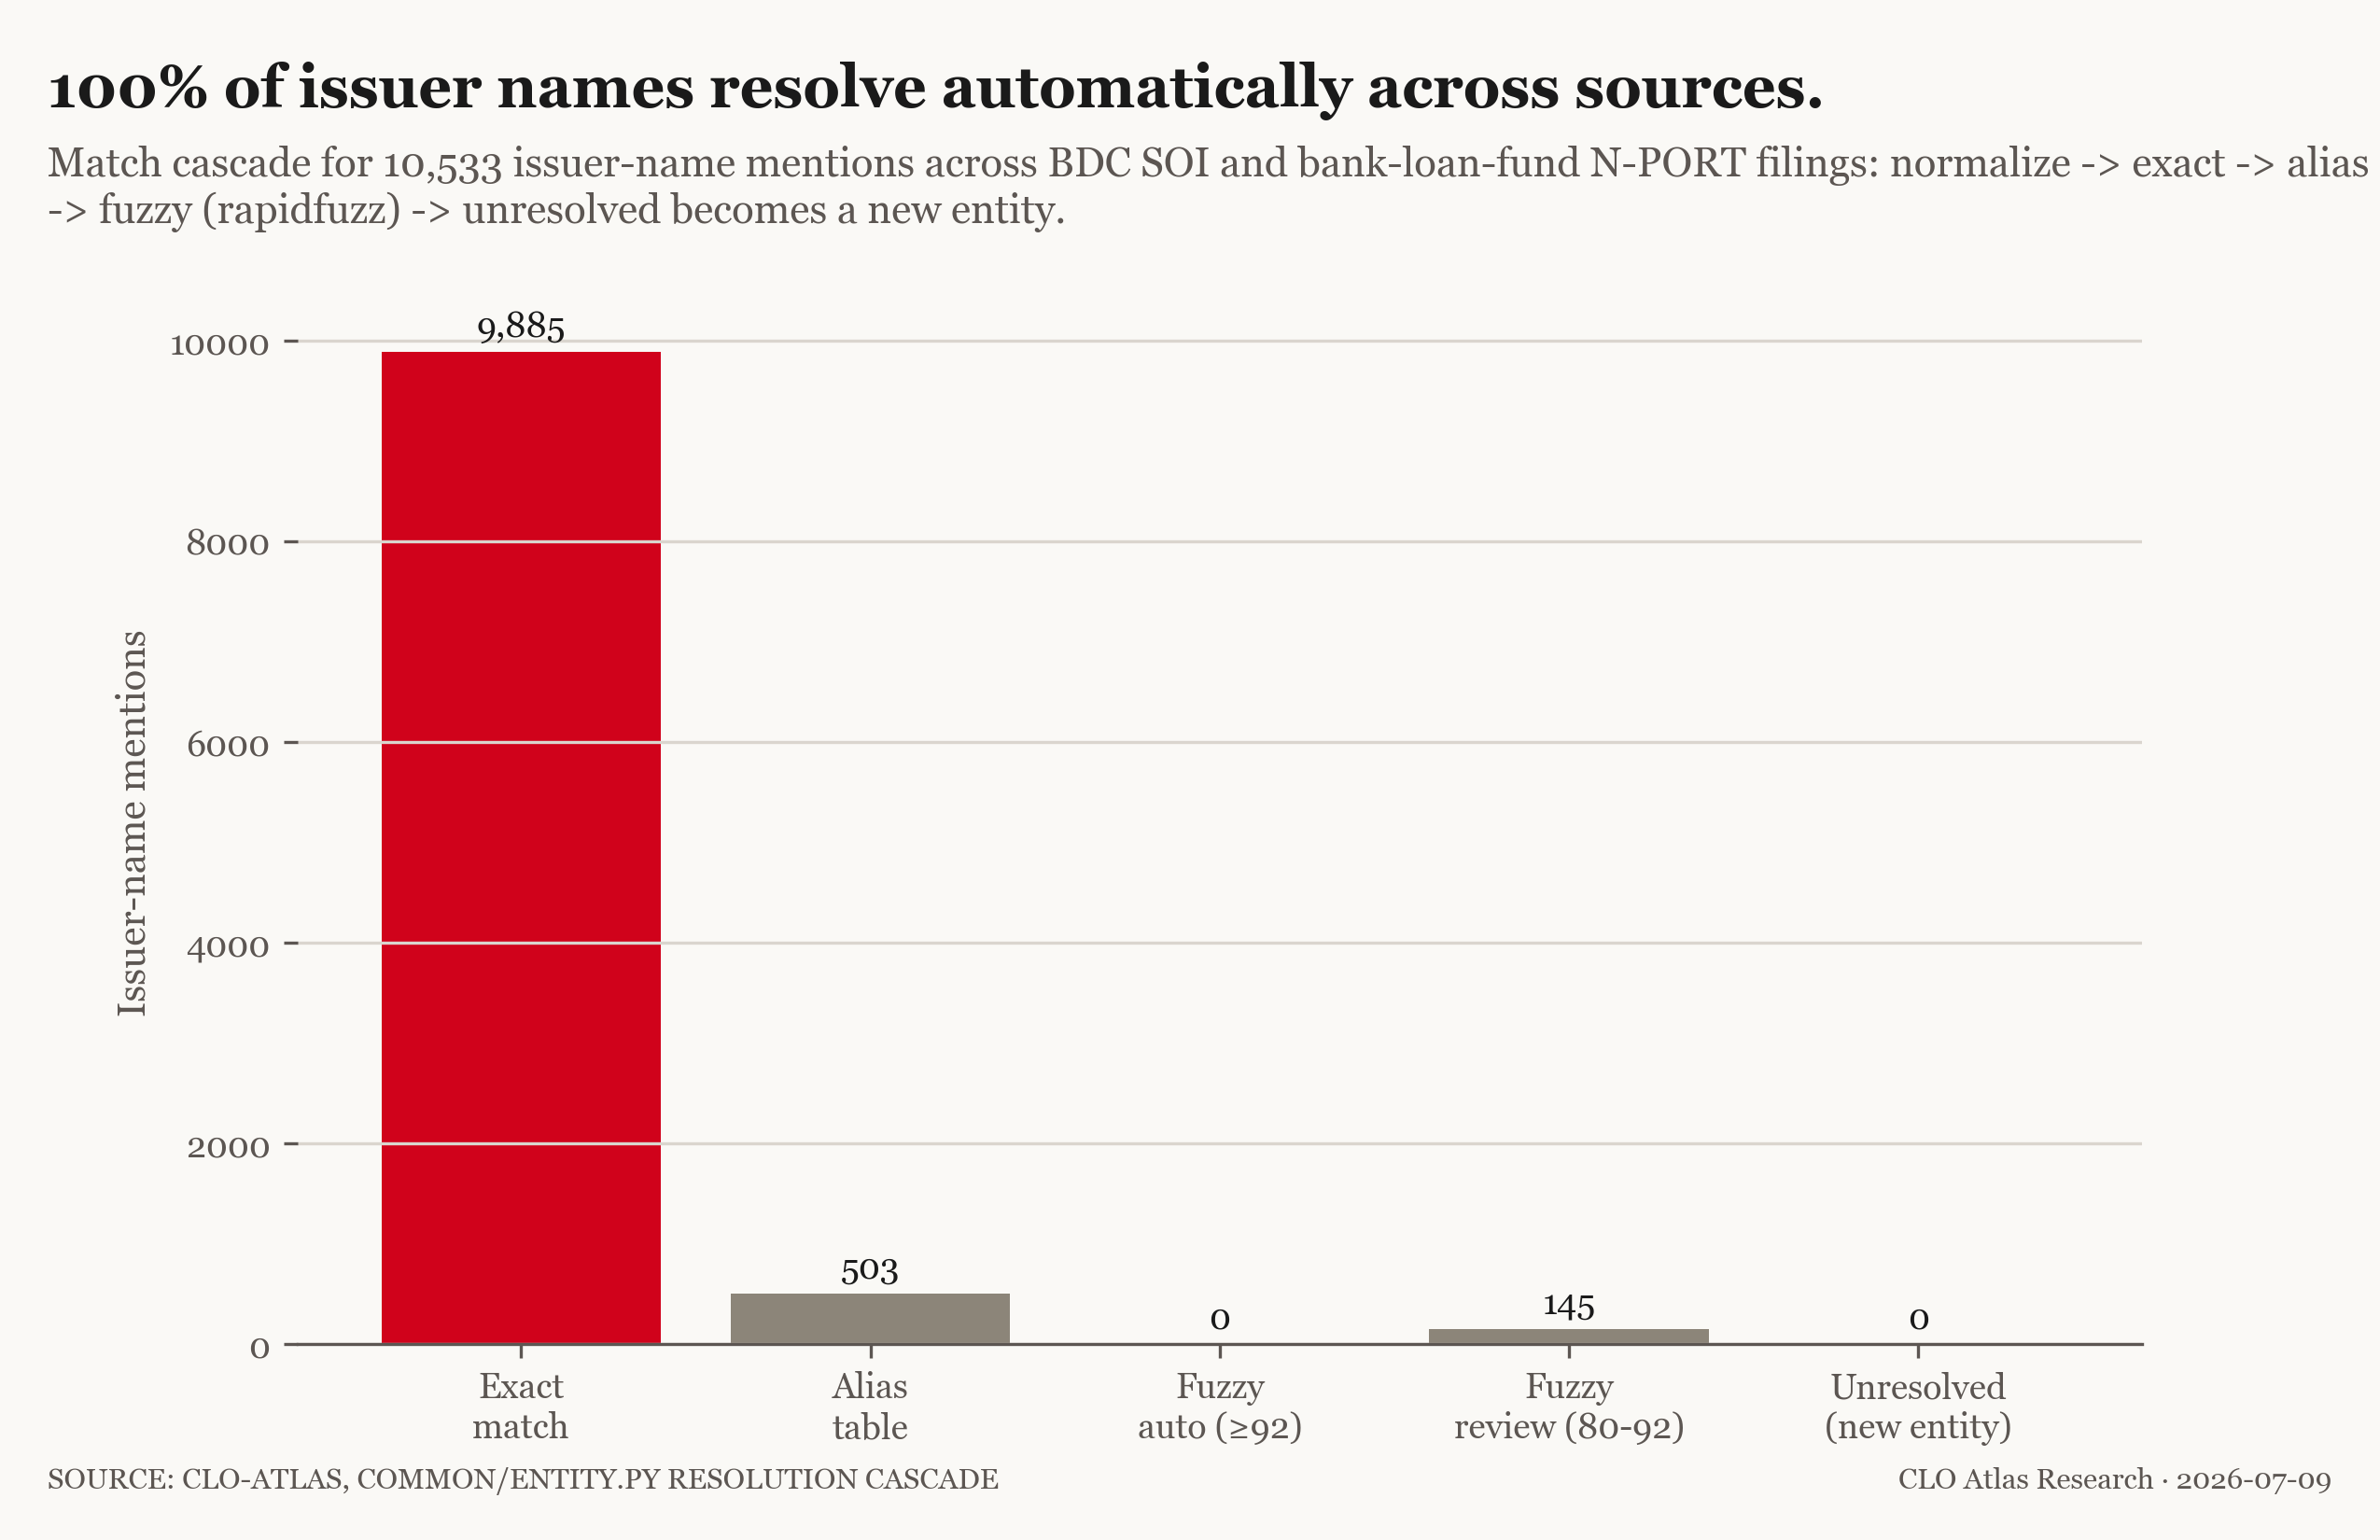

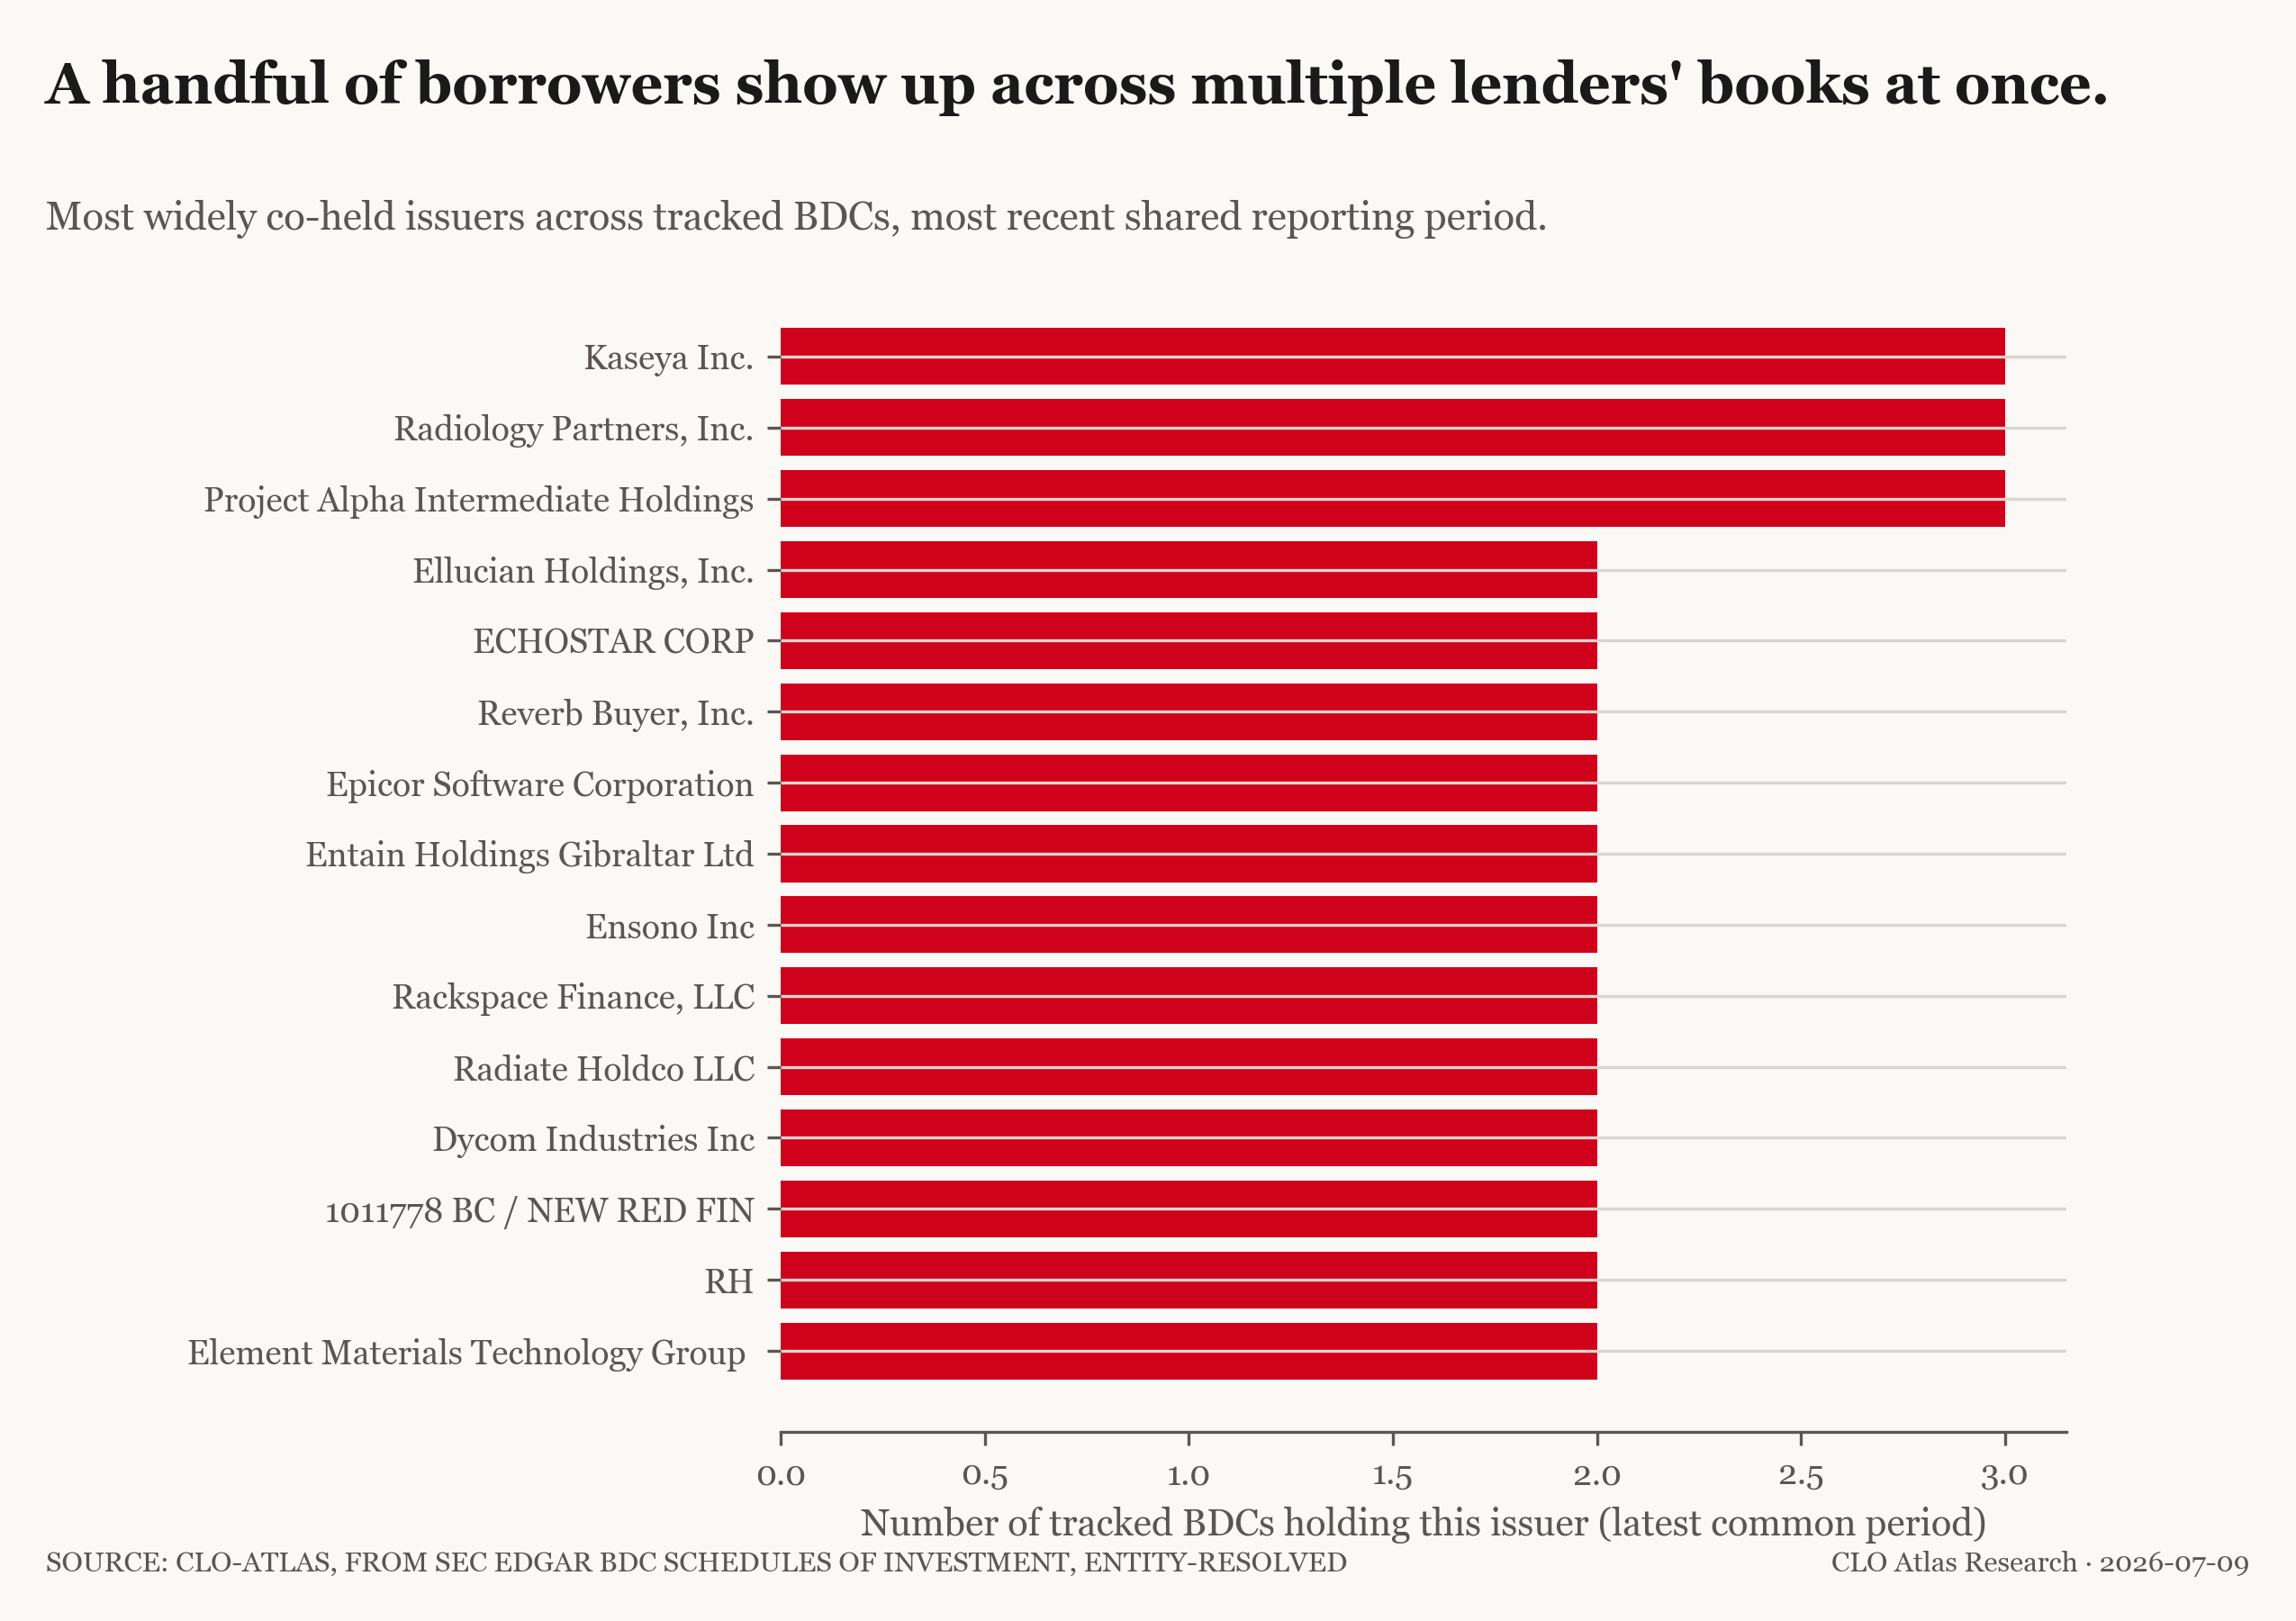

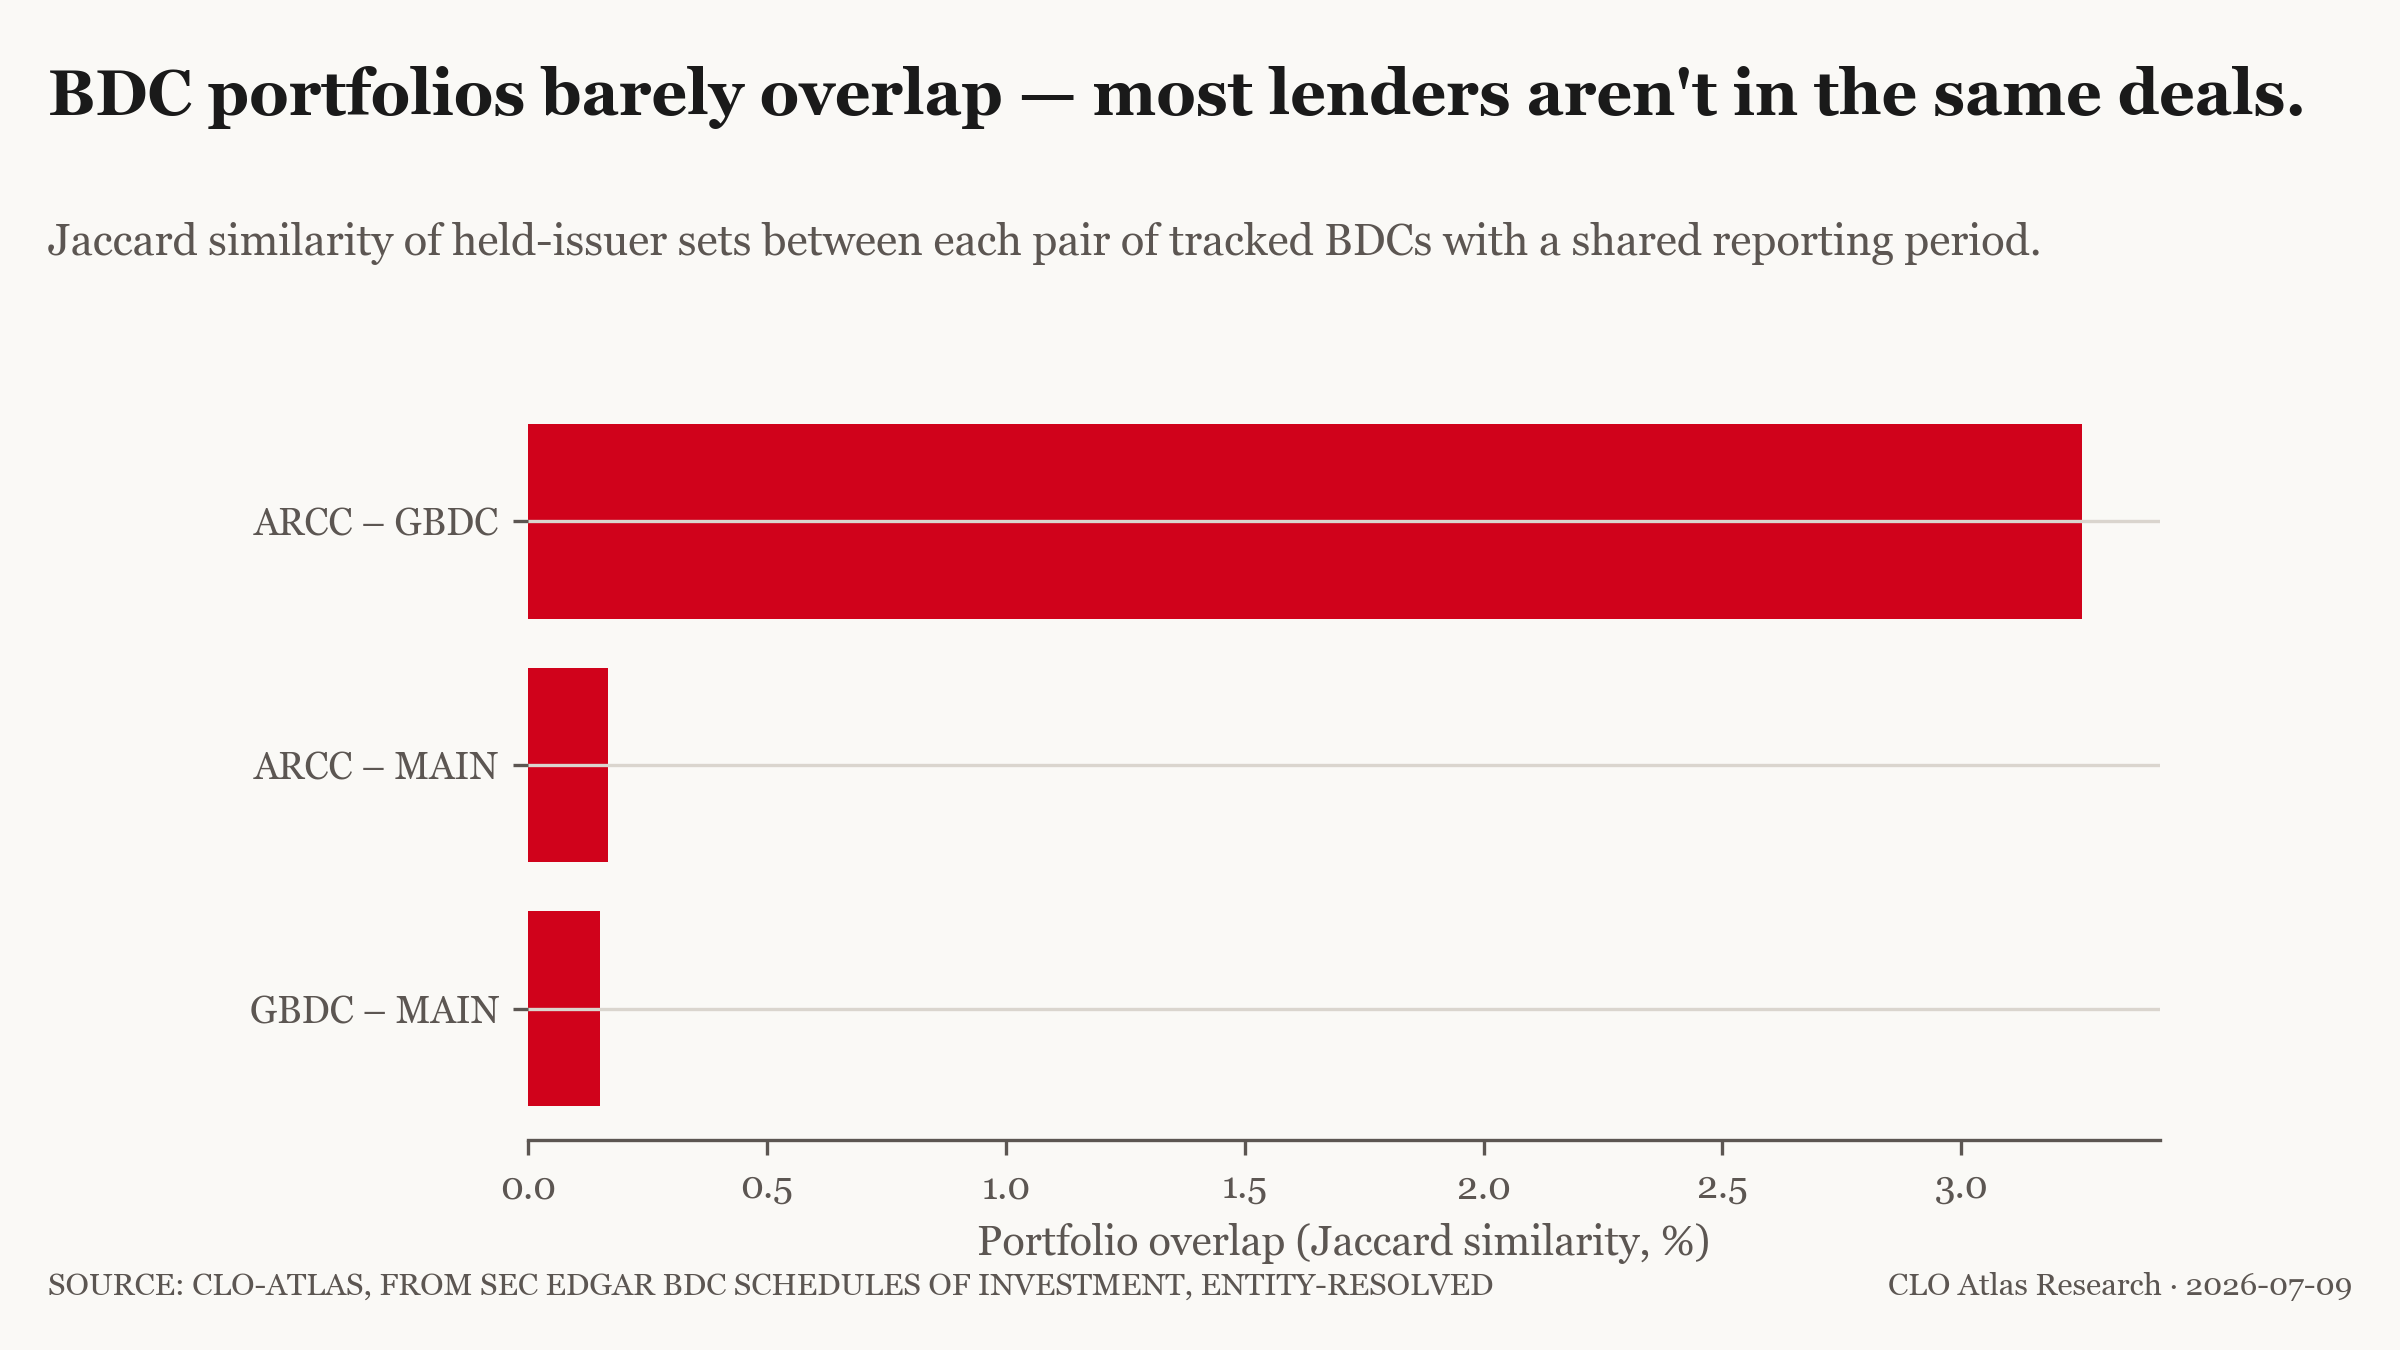

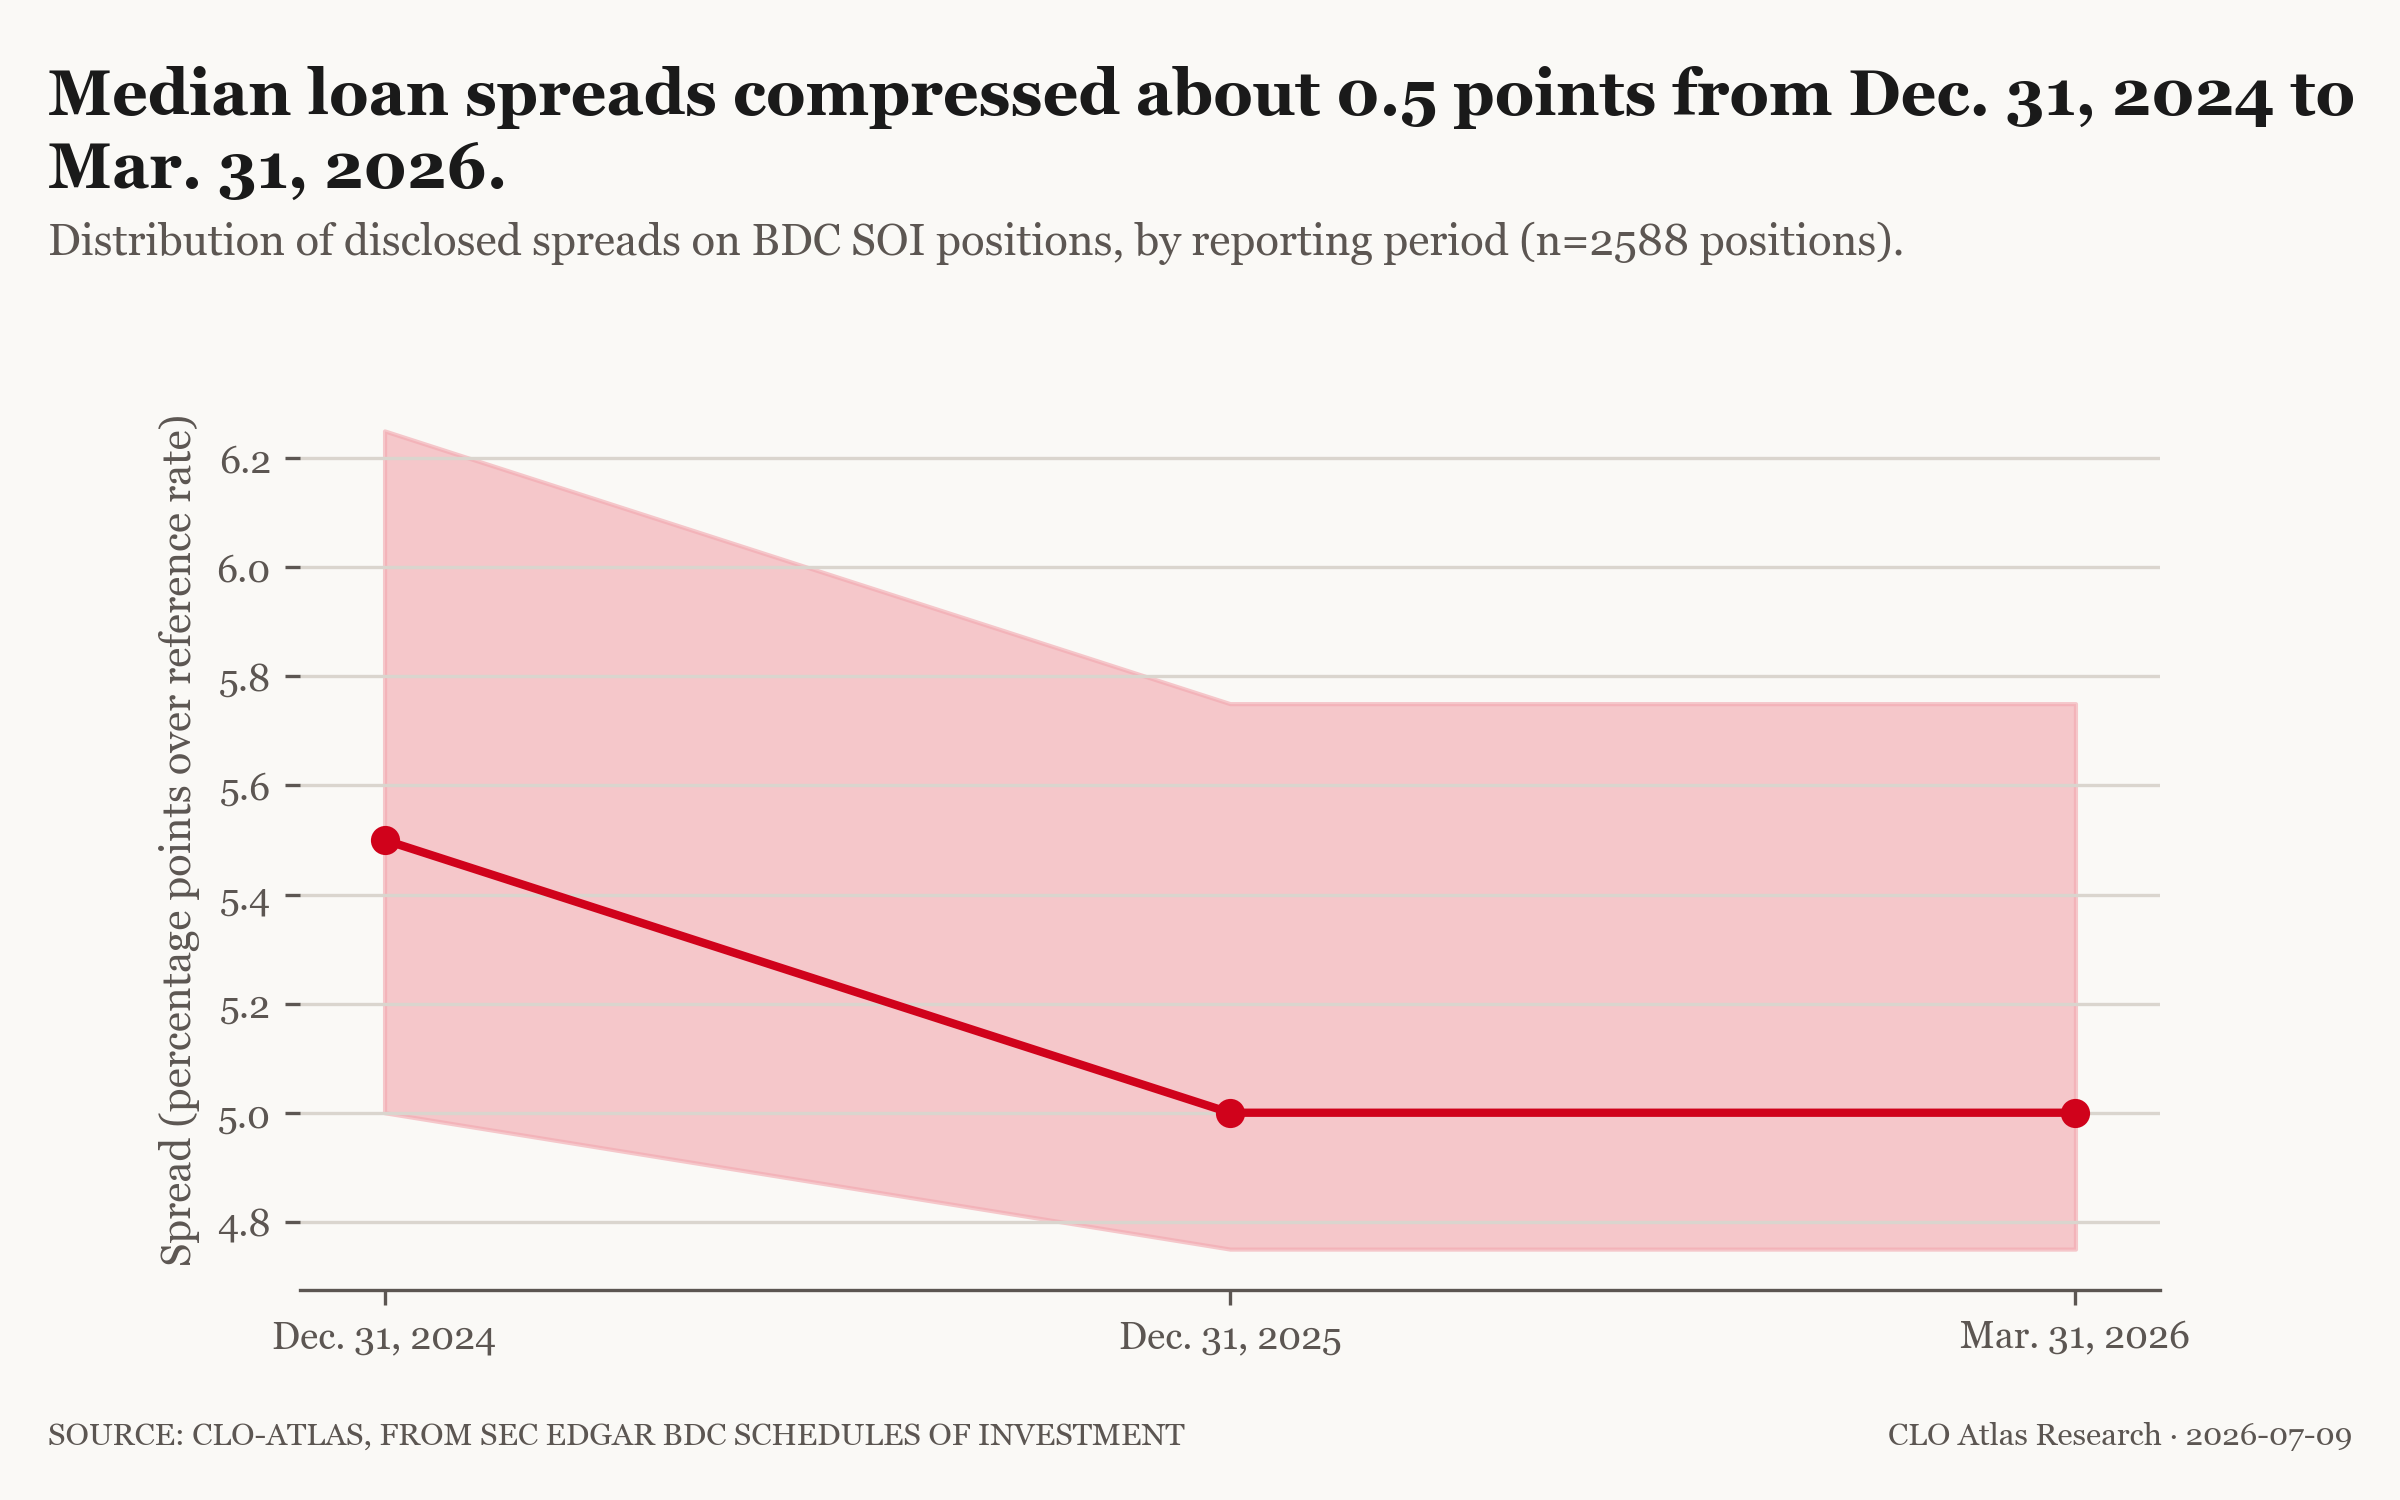

In [5]:
for name in [
    "viz_one_loan_several_prices", "viz_resolution_funnel",
    "viz_top_crowded_issuers", "viz_bdc_overlap", "viz_spread_distribution",
]:
    path = pathlib.Path("../figures") / f"{name}.png"
    if path.exists():
        display(Image(filename=str(path)))
    else:
        print(f"[skipped — not generated this run] {name}")